## Проект: Исследовательский анализ продаж билетов
### Цель: Провести исследовательский анализ данных сервиса продажи билетов и подготовить данные для проверки продуктовых гипотез.  
### Описание данных

В проекте используются три датасета:

1. Первый датасет final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных.  
    order_id — уникальный идентификатор заказа.  
    user_id — уникальный идентификатор пользователя.  
    created_dt_msk — дата создания заказа (московское время).  
    created_ts_msk — дата и время создания заказа (московское время).  
    event_id — идентификатор мероприятия из таблицы events.  
    cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.  
    age_limit — возрастное ограничение мероприятия.  
    currency_code — валюта оплаты, например rub для российских рублей.  
    device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.  
    revenue — выручка от заказа.  
    service_name — название билетного оператора.  
    tickets_count — количество купленных билетов.  
    total — общая сумма заказа.  

2. Второй датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.  

    event_id — уникальный идентификатор мероприятия.  
    event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.  
    event_type_description — описание типа мероприятия.  
    event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.  
    organizers — организаторы мероприятия.  
    region_name — название региона.  
    city_name — название города.  
    venue_id — уникальный идентификатор площадки.  
    venue_name — название площадки.  
    venue_address — адрес площадки.  

3. final_tickets_tenge_df.csv

    nominal — номинал (100 тенге).  
    data — дата.  
    curs — курс тенге к рублю.  
    cdx — обозначение валюты (kzt).  

### Структура проекта

1. Загрузка данных

2. Первичный анализ и знакомство с данными

3. Предобработка данных

4. Создание новых признаков

5. Подготовка итогового датафрейма для анализа

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [3]:
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [4]:
display(orders.head())
display(events.head())
display(tenge.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [5]:
print('Размер orders:', orders.shape)
print('Размер events:', events.shape)
print('Размер tenge:', tenge.shape)

Размер orders: (290849, 14)
Размер events: (22427, 11)
Размер tenge: (357, 4)


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [7]:
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [8]:
print('Пропуски в orders:')
print(orders.isna().sum())

print('Пропуски в events:')
print(events.isna().sum())

print('Пропуски в tenge:')
print(tenge.isna().sum())

Пропуски в orders:
order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64
Пропуски в events:
event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64
Пропуски в tenge:
data       0
nominal    0
curs       0
cdx        0
dtype: int64


Пропуски в days_since_prev ожидаемы, этот столбец содержит количество дней с предыдущей покупки для каждого пользователя, если покупки нет - пропуск

In [9]:
orders.describe()

,order_id,event_id,age_limit,revenue,tickets_count,total,days_since_prev
count,2.908490e+05,290849.000000,290849.000000,290849.000000,290849.000000,290849.000000,268909.000000
mean,4.326812e+06,438079.127702,10.211278,625.083054,2.754230,7526.465613,3.222525
std,2.497578e+06,147396.389016,6.518124,1227.316214,1.170467,15328.267730,11.355158
min,1.000000e+00,4436.000000,0.000000,-90.760000,1.000000,-358.850000,0.000000
25%,2.164039e+06,361961.000000,6.000000,116.790000,2.000000,2156.870000,0.000000
50%,4.327816e+06,498329.000000,12.000000,355.340000,3.000000,4771.390000,0.000000
75%,6.488606e+06,546284.000000,16.000000,809.750000,4.000000,8955.950000,1.000000
max,8.653108e+06,592325.000000,18.000000,81174.540000,57.000000,811745.400000,148.000000


In [10]:
print("Уникальных order_id:", orders['order_id'].nunique())
print('Всего строк:', len(orders))

Уникальных order_id: 290849
Всего строк: 290849


In [11]:
orders['created_dt_msk']=pd.to_datetime(orders['created_dt_msk'])
print('Минимальная дата:', orders['created_dt_msk'].min())
print('Максимальнгая дата:', orders['created_dt_msk'].max())

Минимальная дата: 2024-06-01 00:00:00
Максимальнгая дата: 2024-10-31 00:00:00


In [12]:
orders['currency_code'].value_counts()

rub    285780
kzt      5069
Name: currency_code, dtype: int64

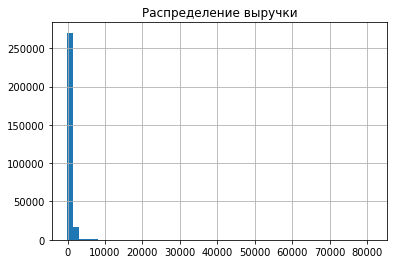

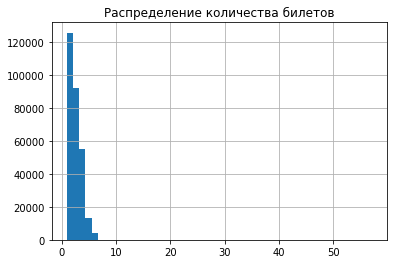

In [13]:
orders['revenue'].hist(bins=50)
plt.title('Распределение выручки')
plt.show()

orders['tickets_count'].hist(bins=50)
plt.title('Распределение количества билетов')
plt.show()

In [14]:
print('Количество явных дубликатов:', orders.duplicated().sum())

Количество явных дубликатов: 0


In [15]:
# объединение датасетов 
df=orders.merge(events, on='event_id', how='left')

print('Размер после объединения:', df.shape)
print('Пропуски после merge:')
print(df.isna().sum())

Размер после объединения: (290849, 24)
Пропуски после merge:
order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64


In [16]:
missing_events = df[df['event_name'].isna()]
print("Количество заказов без события:", missing_events.shape[0])
print("Уникальных event_id без события:", missing_events['event_id'].nunique())

Количество заказов без события: 238
Уникальных event_id без события: 19


In [17]:
df = df[~df['event_name'].isna()]

In [18]:
negative_revenue = orders[orders['revenue'] < 0]
print('Количество возвратов:', negative_revenue.shape[0])
print('Доля возвратов:', negative_revenue.shape[0] / orders.shape[0])

Количество возвратов: 381
Доля возвратов: 0.0013099580882175975


In [19]:
df = df[df['revenue'] >= 0]
df = df[df['total'] >= 0]

В датасете обнаружено 381 заказ с отрицательной выручкой, что составляет 0,13% от общего числа заказов. Данные значения интерпретируются как возвраты. Поскольку их доля крайне незначительна и цель исследования — анализ фактических продаж и покупательской активности, заказы с отрицательной выручкой были исключены из дальнейшего анализа. Удаление 0,13% наблюдений не оказывает существенного влияния на репрезентативность выборки.

In [20]:
tenge['data']=pd.to_datetime(tenge['data'])
tenge['rate_rub']=tenge['curs']/tenge['nominal']

df=df.merge(
    tenge[['data', 'rate_rub']],
    left_on='created_dt_msk',
    right_on='data',
    how='left')

df['revenue_rub']=np.where(
    df['currency_code']=='rub',
    df['revenue'],
    df['revenue']*df['rate_rub'])

In [21]:
p99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= p99]

print('Порог 99 перцентиля:', p99)

Порог 99 перцентиля: 2628.4217390400004


In [22]:
p99_tickets = df['tickets_count'].quantile(0.99)
df = df[df['tickets_count'] <= p99_tickets]
print('Порог по количеству билетов:', p99_tickets)

Порог по количеству билетов: 6.0


In [23]:
df['tickets_count'].describe()

count    287223.000000
mean          2.736463
std           1.136179
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: tickets_count, dtype: float64

In [24]:
# выручка за один билет
df['one_ticket_revenue_rub']=df['revenue_rub']/df['tickets_count']

In [25]:
# месяц
df['month']=df['created_dt_msk'].dt.month

In [26]:
#сезон 
def get_season(month):
        if month in [12, 1, 2]:
            return 'зима'
        elif month in [3,4,5]:
            return 'весна'
        elif month in [6,7,8]:
            return 'лето'
        else:
            return 'осень'
df['season']=df['month'].apply(get_season)

In [27]:
categorical_cols=df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\nСтолбец: {col}')
    print(df[col].unique()[:10])


Столбец: user_id
['0002849b70a3ce2' '0005ca5e93f2cf4' '000898990054619' '00096d1f542ab2b'
 '000a55a418c128c' '000cf0659a9f40f' '00147c9209d45d3' '0018ecd8a38a51b'
 '00199a573901564' '001e7037d013f0f']

Столбец: created_ts_msk
['2024-08-20 16:08:03' '2024-07-23 18:36:24' '2024-10-06 13:56:02'
 '2024-07-13 19:40:48' '2024-10-04 22:33:15' '2024-10-23 15:12:00'
 '2024-08-15 16:48:48' '2024-09-29 19:39:12' '2024-10-15 10:29:04'
 '2024-06-20 10:35:26']

Столбец: cinema_circuit
['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']

Столбец: currency_code
['rub' 'kzt']

Столбец: device_type_canonical
['mobile' 'desktop']

Столбец: service_name
['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры']

Столбец: event_name
['f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad'
 '40efeb04-81b7-4135-b41f-708ff00cc64c'
 '01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca'
 '2f638715-8844-466c-b43f-378a627c419f'
 '10d805d3-9809-4d8

In [28]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].str.strip()

Перед проверкой неявных дубликатов был проведён анализ категориальных переменных на предмет различий в регистре, наличии лишних пробелов и дублирующихся значений. Аномалий в написании категорий выявлено не было, значения представлены в единообразном формате. Поэтому дополнительная нормализация строковых переменных не потребовалась.

In [29]:
# проверка неявных дубликатов
dup_df = df[df.duplicated(subset=[
    'user_id',
    'created_ts_msk',
    'event_id',
    'tickets_count',
    'total'
], keep=False)].sort_values('created_ts_msk')

dup_df.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,data,rate_rub,revenue_rub,one_ticket_revenue_rub,month,season
232190,7927528,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",2024-06-19,0.192165,0.00,0.000000,6,лето
232187,1585808,c7a762e320f0def,2024-06-19,2024-06-19 11:07:59,538926,нет,18,rub,mobile,0.00,...,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",2024-06-19,0.192165,0.00,0.000000,6,лето
285007,8548070,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,989.57,329.856667,6,лето
285006,8548041,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,989.57,329.856667,6,лето
285011,8547867,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,1319.43,329.857500,6,лето
285004,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,1319.43,329.857500,6,лето
285003,8547983,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,1319.43,329.857500,6,лето
285001,8547809,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,989.57,329.856667,6,лето
285008,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",2024-06-19,0.192165,989.57,329.856667,6,лето
176097,8248210,8f95286aa5fd8d7,2024-06-20,2024-06-20 10:57:19,244875,нет,0,rub,mobile,15.73,...,12.0,2492.0,"Кинофестиваль ""Хранитель"" Инкорпорэйтед","пр. Балтийский, д. 8 к. 51",2024-06-20,0.180419,15.73,5.243333,6,лето


In [30]:
df = df.drop_duplicates(subset=[
    'user_id',
    'created_ts_msk',
    'event_id',
    'tickets_count',
    'total'
])

In [31]:
print('Неявные дубликаты после удаления:',
      df.duplicated(subset=[
          'user_id',
          'created_ts_msk',
          'event_id',
          'tickets_count',
          'total'
      ]).sum())

Неявные дубликаты после удаления: 0


In [32]:
df = df.copy()

df[['age_limit', 'tickets_count']] = (
    df[['age_limit', 'tickets_count']].astype(int)
)

In [33]:
print('Итоговый размер датасета:', df.shape)

df.describe()
df.head()

Итоговый размер датасета: (287179, 30)


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,data,rate_rub,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972,1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,0.183419,289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,0.196475,1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,0.185010,8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,0.196648,1390.41,463.4700,10,осень


In [34]:
(df['revenue_rub'] < 0).sum()

0

In [35]:
(df['tickets_count'] == 0).sum()

0

In [36]:
df['rate_rub'].isna().sum()

0

In [37]:
df.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
Int64Index: 287179 entries, 0 to 290227
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287179 non-null  int64         
 1   user_id                 287179 non-null  object        
 2   created_dt_msk          287179 non-null  datetime64[ns]
 3   created_ts_msk          287179 non-null  object        
 4   event_id                287179 non-null  int64         
 5   cinema_circuit          287179 non-null  object        
 6   age_limit               287179 non-null  int64         
 7   currency_code           287179 non-null  object        
 8   device_type_canonical   287179 non-null  object        
 9   revenue                 287179 non-null  float64       
 10  service_name            287179 non-null  object        
 11  tickets_count           287179 non-null  int64         
 12  total                   287179

In [38]:
df['age_limit']= pd.to_numeric(df['age_limit'], downcast='integer')
df['tickets_count']=pd.to_numeric(df['tickets_count'], downcast='integer')

df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')

cat_cols = [
    'cinema_circuit',
    'currency_code',
    'device_type_canonical',
    'service_name',
    'event_type_description',
    'event_type_main',
    'region_name',
    'city_name',
    'venue_name',
    'season'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [39]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287179 entries, 0 to 290227
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287179 non-null  int64         
 1   user_id                 287179 non-null  object        
 2   created_dt_msk          287179 non-null  datetime64[ns]
 3   created_ts_msk          287179 non-null  object        
 4   event_id                287179 non-null  int64         
 5   cinema_circuit          287179 non-null  category      
 6   age_limit               287179 non-null  int8          
 7   currency_code           287179 non-null  category      
 8   device_type_canonical   287179 non-null  category      
 9   revenue                 287179 non-null  float64       
 10  service_name            287179 non-null  category      
 11  tickets_count           287179 non-null  int8          
 12  total                   287179

В рамках промежуточного этапа проекта была проведена комплексная очистка и подготовка данных к дальнейшему анализу. Исходный датасет содержал около 290 тысяч заказов. На этапе предобработки были удалены записи без привязки к событию, заказы с отрицательной выручкой и некорректным значением total, а также выбросы по выручке выше 99-го перцентиля, что позволило устранить аномально крупные значения, искажающие анализ. Дополнительно были обнаружены и удалены 44 неявных дубликата заказов на основе бизнес-ключа (user_id, дата создания, event_id, количество билетов и сумма заказа). В результате итоговый датасет сократился незначительно (примерно на 1–1,5%), что говорит о хорошем качестве исходных данных.

Была выполнена корректная обработка валют: для заказов в тенге произведён пересчёт в рубли по курсу на соответствующую дату, после чего вся выручка приведена к единой валюте. Далее были созданы новые аналитические признаки — выручка за один билет, месяц покупки и сезон, что расширяет возможности дальнейшего анализа поведения пользователей и сезонности продаж.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

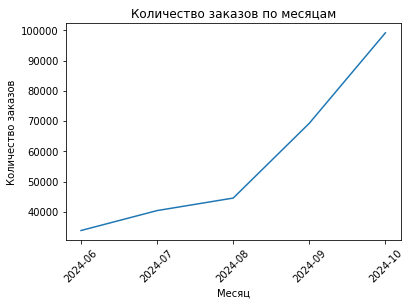

In [40]:
# Количество заказов по месяцам
orders_by_month = (
    df.groupby(df['created_dt_msk'].dt.to_period('M'))
      .agg(orders=('order_id', 'nunique'))
      .reset_index()
)

orders_by_month['created_dt_msk'] = orders_by_month['created_dt_msk'].astype(str)

plt.figure()
plt.plot(orders_by_month['created_dt_msk'],
         orders_by_month['orders'])
plt.xticks(rotation=45)
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

In [41]:
# ф-я для расчета долей
def segment_share(data, segment):
    table = (
        data.groupby(['season', segment])
            .agg(orders=('order_id', 'nunique'))
            .reset_index()
    )
    
    table['share'] = (
        table['orders'] /
        table.groupby('season')['orders'].transform('sum')
    )
    
    return table

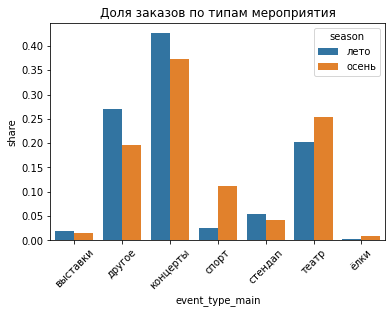

In [42]:
# тип мероприятия
event_share = segment_share(df, 'event_type_main')

plt.figure()
sns.barplot(data=event_share,
           x='event_type_main',
           y='share',
           hue='season')
plt.xticks(rotation=45)
plt.title('Доля заказов по типам мероприятия')
plt.show()

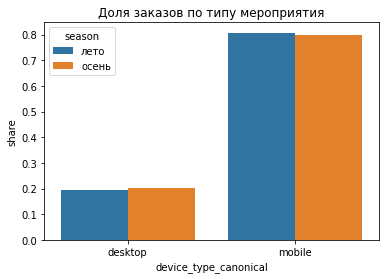

In [43]:
# тип устройства
device_share=segment_share(df, 'device_type_canonical')
plt.figure()
sns.barplot(data=device_share,
           x='device_type_canonical',
           y='share',
           hue='season')
plt.title('Доля заказов по типу мероприятия')
plt.show()

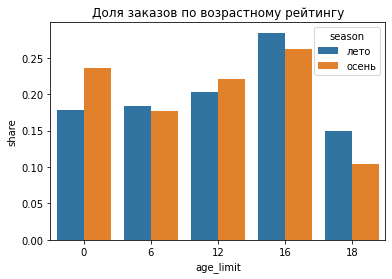

In [44]:
# Возрастной рейтинг
age_share=segment_share(df, 'age_limit')
plt.figure()
sns.barplot(data=age_share,
           x='age_limit',
           y='share',
           hue='season')
plt.title('Доля заказов по возрастному рейтингу')
plt.show()


In [45]:
df['price_per_ticket'] = df['revenue_rub'] / df['tickets_count']
price_by_type = (
    df.groupby(['season', 'event_type_main'])
      .agg(mean_price=('price_per_ticket', 'mean'))
      .reset_index()
)

pivot_price = price_by_type.pivot(
    index='event_type_main',
    columns='season',
    values='mean_price'
)

pivot_price = pivot_price.reindex(columns=['лето', 'осень'])

# Считаем относительное изменение
pivot_price['relative_change_%'] = (
    (pivot_price['осень'] - pivot_price['лето']) /
    pivot_price['лето'] * 100
)

pivot_price = pivot_price.reset_index()

pivot_price

season,event_type_main,лето,осень,relative_change_%
0,выставки,86.744476,91.905090,5.949214
1,другое,77.790535,76.425087,-1.755288
2,концерты,302.357269,269.342957,-10.918974
3,спорт,50.796204,50.039795,-1.489105
4,стендап,218.585831,231.466949,5.892934
5,театр,214.439651,176.253494,-17.807413
6,ёлки,271.436188,230.289597,-15.158846


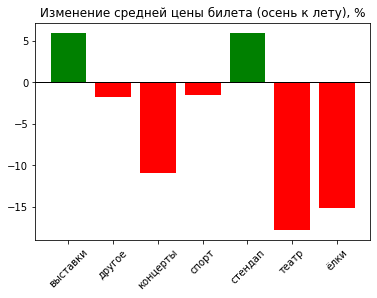

In [46]:
plt.figure()

# формируем цвета: зеленый если рост, красный если падение
colors = ['green' if x > 0 else 'red' for x in pivot_price['relative_change_%']]

plt.bar(
    pivot_price['event_type_main'],
    pivot_price['relative_change_%'],
    color=colors
)

plt.xticks(rotation=45)
plt.title('Изменение средней цены билета (осень к лету), %')
plt.axhline(0, color='black', linewidth=1)  # линия нулевого изменения

plt.show()

<div class="alert alert-info"> <b>Комментарий студента:</b> Добавила</div>

### Осенняя активность пользователей

In [50]:
df_autumn=df[df['season']=='осень'].copy()

In [51]:
daily_stats = (
    df_autumn.groupby(df_autumn['created_dt_msk'].dt.date)
        .agg(
            orders=('order_id', 'nunique'),
            dau=('user_id', 'nunique'),
            revenue=('revenue_rub', 'sum'),
            tickets=('tickets_count', 'sum'))
            .reset_index())
daily_stats['orders_per_user']=daily_stats['orders']/daily_stats['dau']
daily_stats['avg_tickets_price']=daily_stats['revenue']/daily_stats['tickets']

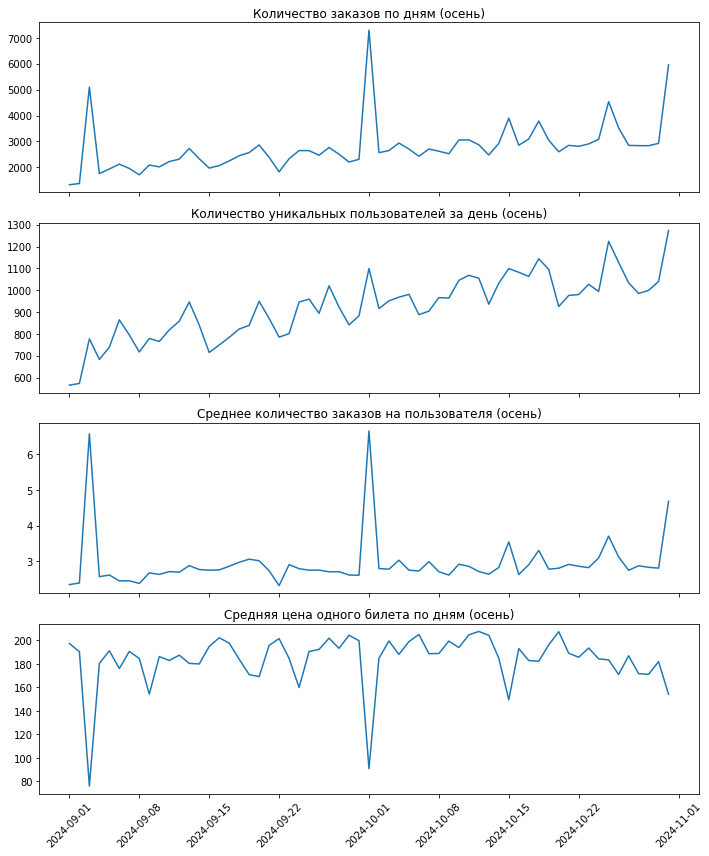

In [52]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# 1. Количество заказов
axes[0].plot(daily_stats['created_dt_msk'], daily_stats['orders'])
axes[0].set_title('Количество заказов по дням (осень)')

# 2. DAU
axes[1].plot(daily_stats['created_dt_msk'], daily_stats['dau'])
axes[1].set_title('Количество уникальных пользователей за день (осень)')

# 3. Заказы на пользователя
axes[2].plot(daily_stats['created_dt_msk'], daily_stats['orders_per_user'])
axes[2].set_title('Среднее количество заказов на пользователя (осень)')

# 4. Средняя цена билета
axes[3].plot(daily_stats['created_dt_msk'], daily_stats['avg_tickets_price'])
axes[3].set_title('Средняя цена одного билета по дням (осень)')

# Общие настройки
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

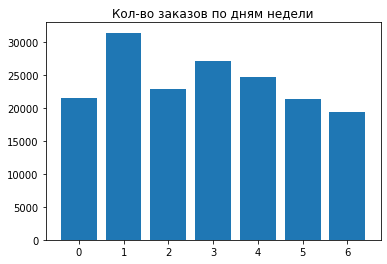

In [112]:
# недельная цикличность 
df_autumn['weekday'] = df_autumn['created_dt_msk'].dt.weekday

weekday_stats = (
    df_autumn.groupby('weekday')
        .agg(
            orders=('order_id', 'nunique'),
            dau=('user_id', 'nunique')
        )
        .reset_index())
plt.figure()
plt.bar(weekday_stats['weekday'],
       weekday_stats['orders'])
plt.title('Кол-во заказов по дням недели')
plt.show()

### Регионы и партнёры


In [54]:
# анализ регионов
region_stats = (
    df.groupby('region_name')
      .agg(
          unique_events=('event_id', 'nunique'),
          orders=('order_id', 'nunique'),
          revenue=('revenue_rub', 'sum')
      )
      .reset_index()
)

region_stats['orders_share'] = (
    region_stats['orders'] /
    region_stats['orders'].sum()
)

region_stats.sort_values('orders', ascending=False).head()

,region_name,unique_events,orders,revenue,orders_share
23,Каменевский регион,5937,89717,56104524.00,0.312408
60,Североярская область,3795,43620,22012508.00,0.151891
77,Широковская область,1225,16097,8634904.00,0.056052
42,Медовская область,503,13888,2928166.75,0.048360
45,Озернинский край,349,10403,9553401.00,0.036225


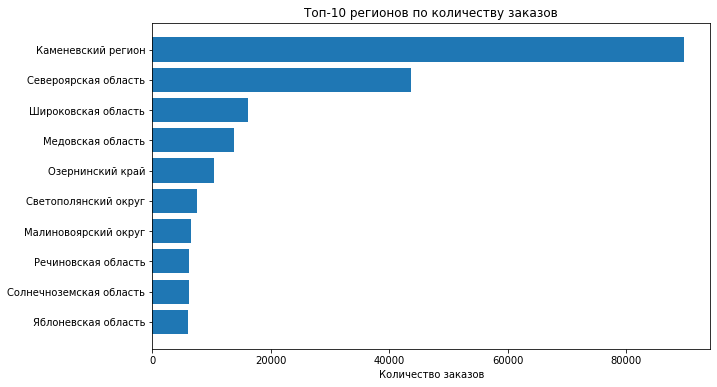

In [55]:
top_regions = region_stats.sort_values('orders', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_regions['region_name'], top_regions['orders'])
plt.xlabel('Количество заказов')
plt.title('Топ-10 регионов по количеству заказов')
plt.gca().invert_yaxis()
plt.show()

In [114]:
partner_stats = (
    df.groupby('organizers')
      .agg(
          unique_events=('event_id', 'nunique'),
          orders=('order_id', 'nunique'),
          revenue=('revenue_rub', 'sum')
      )
      .reset_index()
)

partner_stats['revenue_share'] = (
    partner_stats['revenue'] /
    partner_stats['revenue'].sum()
)

partner_stats.sort_values('revenue', ascending=False).head()

,organizers,unique_events,orders,revenue,revenue_share
3043,№4054,10,4328,4514389.50,0.030318
3075,№4086,24,3291,3399699.00,0.022832
3936,№4950,8,2864,3207496.50,0.021541
3390,№4403,31,2954,2848966.00,0.019133
1115,№2121,46,4721,2195338.75,0.014743


## Промежуточный вывод
 ### Анализ распределения заказов по сегментам и сезонные изменения

Анализ показал наличие сезонности: количество заказов постепенно увеличивается с июня и достигает максимума к осени.

Распределение заказов по типам устройств показывает, что большинство пользователей покупают билеты с мобильных устройств, доля десктопа значительно ниже.

По возрастным рейтингам наибольшая доля заказов приходится на мероприятия категории 16+, затем следуют 12+ и 6+.

Сравнение средней стоимости билетов показывает разнонаправленную динамику. Осенью цена увеличилась для выставок и стендапа, тогда как для концертов, театра и категории ёлки наблюдается снижение.

 ### Осенняя активность пользователей

Осенью наблюдается рост пользовательской активности. Количество заказов и число активных пользователей постепенно увеличиваются.

Среднее количество заказов на одного пользователя остаётся относительно стабильным, что говорит о том, что рост заказов происходит в основном за счёт увеличения числа пользователей.

Средняя стоимость билета по дням существенно не меняется, однако наблюдаются отдельные колебания.

Анализ по дням недели показывает наличие недельной цикличности: в начале недели заказов больше, чем в конце.

 ### Популярные регионы и партнёры

Распределение заказов по регионам неравномерно. Наибольшая доля заказов приходится на Каменевский регион, который формирует около трети всех заказов. Также заметный вклад вносят Североярская и Широковская области.

Анализ организаторов показывает, что существует большое количество партнёров, однако основная часть заказов и выручки приходится на ограниченное число наиболее активных организаторов.

## Статистический анализ данных

Формулировка гипотез

H₀: Среднее количество заказов на пользователя мобильных устройств не выше, чем у пользователей стационарных устройств.   
H₁: Среднее количество заказов на пользователя мобильных устройств выше, чем у пользователей стационарных устройств.

In [56]:
orders_per_user = (
    df_autumn
    .groupby(['device_type_canonical', 'user_id'])
    .agg(orders=('order_id','nunique'))
    .reset_index()
)

In [57]:
mobile_orders = orders_per_user[
    orders_per_user['device_type_canonical'] == 'mobile'
]['orders']

desktop_orders = orders_per_user[
    orders_per_user['device_type_canonical'] == 'desktop'
]['orders']

In [58]:
alpha = 0.05

results = st.ttest_ind(
    mobile_orders,
    desktop_orders,
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-value: 8.122953754954212e-32
Отвергаем нулевую гипотезу


In [59]:
df_autumn = df_autumn.sort_values(['user_id','created_dt_msk'])

df_autumn['time_diff'] = (
    df_autumn
    .groupby('user_id')['created_dt_msk']
    .diff()
    .dt.days
)

In [60]:
time_between = df_autumn.dropna(subset=['time_diff'])

In [61]:
mobile_time = time_between[
    time_between['device_type_canonical']=='mobile'
]['time_diff']

desktop_time = time_between[
    time_between['device_type_canonical']=='desktop'
]['time_diff']

Формулировка гипотез

H0: Среднее время между заказами одинаково.

H1: Среднее время между заказами выше у mobile.

In [62]:
results = st.ttest_ind(
    mobile_time,
    desktop_time,
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

p-value: 1.7927870973544123e-25
Отвергаем нулевую гипотезу


Для проверки гипотез использовались данные только за осенний период.
Сравниваются две независимые выборки пользователей:

 - пользователи мобильных устройств (mobile)

 - пользователи стационарных устройств (desktop)

Для проверки гипотез используется t-тест для независимых выборок из библиотеки scipy.stats.
t-тест используется, поскольку сравниваются средние значения двух независимых выборок, выборки имеют достаточно большой размер, необходимо определить, существует ли статистически значимое различие средних

Параметр equal_var=False применяется, поскольку дисперсии выборок могут различаться.

Гипотеза 1
Среднее количество заказов на пользователя

H₀: Среднее количество заказов на пользователя мобильных устройств не выше, чем у пользователей стационарных устройств.

H₁: Среднее количество заказов на пользователя мобильных устройств выше, чем у пользователей стационарных устройств.
Вывод:
Среднее количество заказов на пользователя мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

Гипотеза 2
Среднее время между заказами

H₀: Среднее время между заказами пользователей мобильных и стационарных устройств одинаково.

H₁: Среднее время между заказами пользователей мобильных устройств выше, чем у пользователей стационарных устройств.
Вывод:
Среднее время между заказами пользователей мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

### Промежуточный вывод

Результаты статистических тестов показали наличие значимых различий между пользователями мобильных и стационарных устройств. Пользователи мобильных устройств в среднем совершают больше заказов, однако время между их заказами также больше. Это может указывать на различия в поведении пользователей разных типов устройств.

## Общий вывод и рекомендации

В ходе проекта был проведён исследовательский анализ данных сервиса продажи билетов. В работе использовались три датасета: данные о заказах пользователей, информация о мероприятиях и данные о курсе тенге к рублю. В процессе анализа данные были очищены от пропусков и выбросов, объединены в единый датафрейм и дополнены новыми признаками, такими как сезон, месяц и выручка в рублях.

Анализ показал, что наиболее востребованными являются мероприятия из категории культурных событий, таких как театральные постановки и концерты. Осенью наблюдается увеличение пользовательской активности и количества заказов по сравнению с летним периодом. Это может быть связано с началом культурного сезона и увеличением числа мероприятий.

Средний чек демонстрирует рост в осенний период, что может указывать на более высокий спрос на мероприятия или на посещение более дорогих событий. Анализ пользовательской активности показывает, что пользователи чаще приобретают несколько билетов за один заказ, что может говорить о посещении мероприятий группами.

Также анализ показал, что существуют регионы и партнёры, которые являются явными лидерами по количеству заказов и выручке. Это может быть связано с более высокой плотностью населения, развитой инфраструктурой мероприятий или активной работой организаторов.

Проверка статистических гипотез показала, что пользователи мобильных устройств в среднем совершают больше заказов по сравнению с пользователями стационарных устройств. Также было выявлено, что время между заказами у пользователей мобильных устройств статистически значимо выше. Это подтверждает наличие различий в пользовательском поведении в зависимости от типа устройства.

## Рекомендации

На основе проведённого анализа можно предложить следующие рекомендации:

Уделить особое внимание развитию мобильного приложения, поскольку пользователи мобильных устройств демонстрируют более высокую активность.

Активнее продвигать мероприятия в осенний период, когда наблюдается рост пользовательской активности и спроса.

Развивать сотрудничество с регионами и партнёрами, которые уже показывают высокие показатели продаж, а также анализировать их успешные практики.

Использовать данные о пользовательском поведении для персонализации рекомендаций и предложений мероприятий.

Продолжить анализ пользовательской активности для выявления факторов, влияющих на рост среднего чека и количества заказов.

Таким образом, проведённый анализ позволил выявить ключевые закономерности пользовательского поведения и определить направления для дальнейшего развития сервиса.